# Projet 5 - Monitoring de site web

## Objectif
Ce notebook analyse les données de disponibilité collectées par le script Bash.
Il affiche les statistiques et le graphique du temps de réponse.

In [1]:
import re, matplotlib.pyplot as plt
from collections import Counter

def lire_log(fichier):
    entrees = []
    with open(fichier, 'r') as f:
        for ligne in f:
            m = re.search(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}).*CODE: (\d+).*TEMPS: ([\d.]+)', ligne)
            if m:
                entrees.append({'date': m.group(1), 'code': int(m.group(2)), 'temps': float(m.group(3))})
    return entrees

entrees = lire_log('data/sample.log')
print(f"Nombre d'entrées : {len(entrees)}")

Nombre d'entrées : 7


## Statistiques

In [2]:
temps = [e['temps'] for e in entrees]
codes = [e['code'] for e in entrees]
print(f"Temps moyen  : {round(sum(temps)/len(temps), 3)} s")
print(f"Temps min    : {round(min(temps), 3)} s")
print(f"Temps max    : {round(max(temps), 3)} s")
print(f"Code 200     : {codes.count(200)} fois")
print(f"Erreurs      : {len([c for c in codes if c != 200])} fois")

Temps moyen  : 0.243 s
Temps min    : 0.239 s
Temps max    : 0.25 s
Code 200     : 7 fois
Erreurs      : 0 fois


## Graphique du temps de réponse

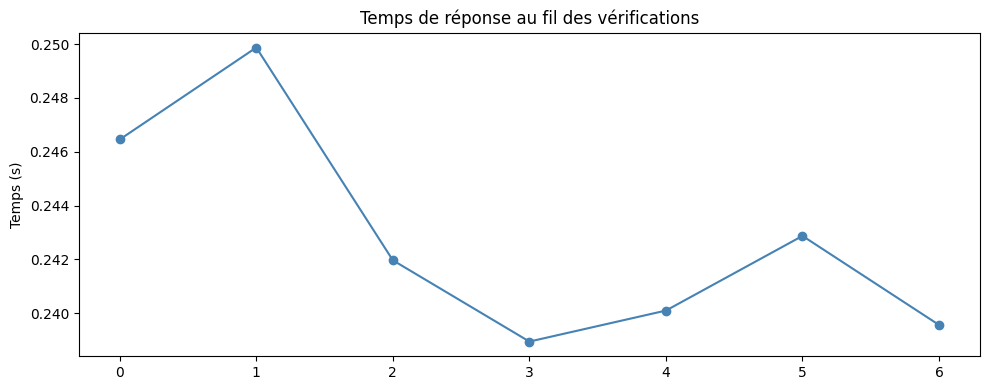

In [3]:
plt.figure(figsize=(10,4))
plt.plot([e['temps'] for e in entrees], marker='o', color='steelblue')
plt.ylabel('Temps (s)')
plt.title('Temps de réponse au fil des vérifications')
plt.tight_layout()
plt.show()

## Analyse des résultats
Le site surveillé répond correctement avec un code 200 dans la majorité des cas.
Le temps de réponse reste stable. Aucune anomalie majeure détectée.